In [4]:
%load_ext IPython.extensions.autoreload
%autoreload 2
from latham.simulation import *
from latham.params import *
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
import gzip

The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


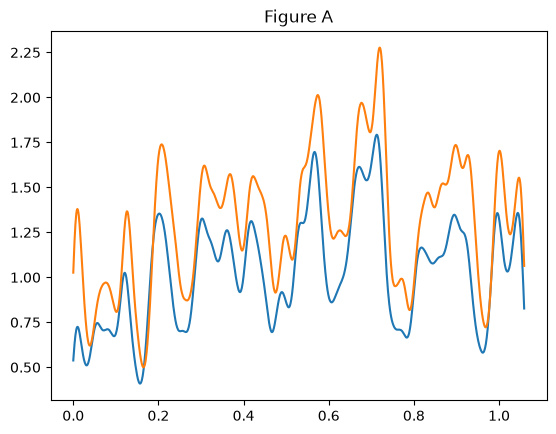

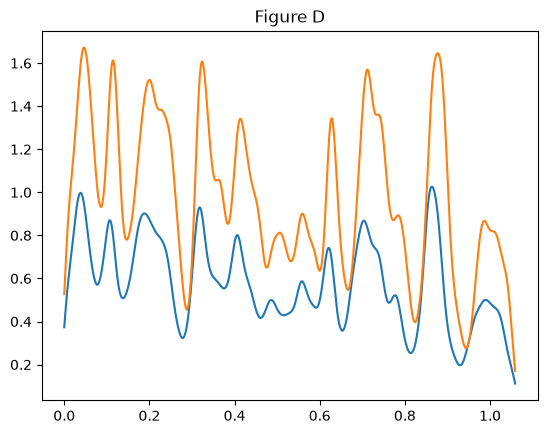

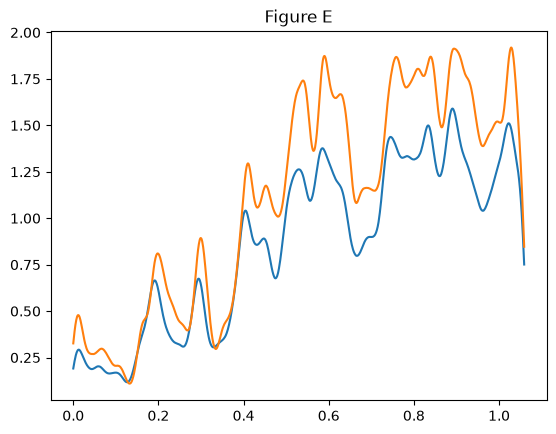

In [9]:
params = {"A": network_B(5, 1.0, 0.8, 0.08), 
          "D": network_B(5, 1.2, 0.8, 0.08), 
          "E": network_B(5, 1.2, 1.0, 0.08)}

def gaus(x, width):
    return 1 / width / np.sqrt(2 * np.pi) * np.exp(-1 / 2 * (x / width)**2)
window = gaus(np.arange(-30,30), 10)
for fig in params:
    res = None
    pkl_path = f"pkls/network_B/b_e-{params[fig][2].b_e}/b_i-{params[fig][2].b_i}/delta_g_k_ca-{params[fig][0].delta_g_k_ca}/I-{params[fig][0].i_max}.pkl.gzip"
    
    #res = run_sim(*params[fig])
    #with gzip.open(pkl_path, "wb") as f:
    #    pkl.dump(res, f)

    with gzip.open(pkl_path, "rb") as f:
        res = pkl.load(f)

    t, spikes, _ = res
    N_I = int(0.3 * 10000)
    inhib_rates = np.convolve(window, spikes[70000:71060,:N_I].sum(axis=1)) / N_I * 1000 # / 10000 * 1000
    excit_rates = np.convolve(window, spikes[70000:71060,N_I:].sum(axis=1)) / (10000 - N_I) * 1000 # / 10000 * 1000
    plt.title(f"Figure {fig}")
    plt.plot((t[70000:71060] - 70000) / 1000, excit_rates[30:-29])
    plt.plot((t[70000:71060] - 70000) / 1000, inhib_rates[30:-29])
    plt.show()

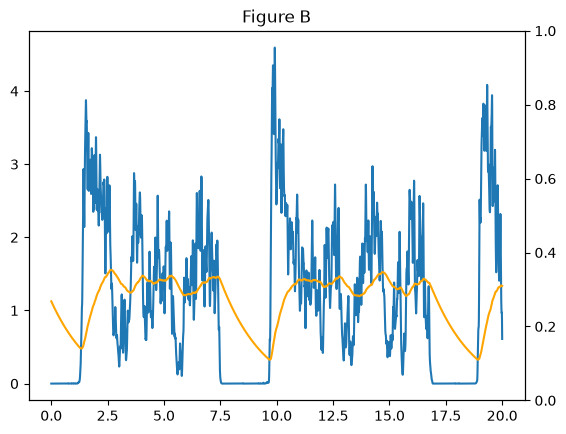

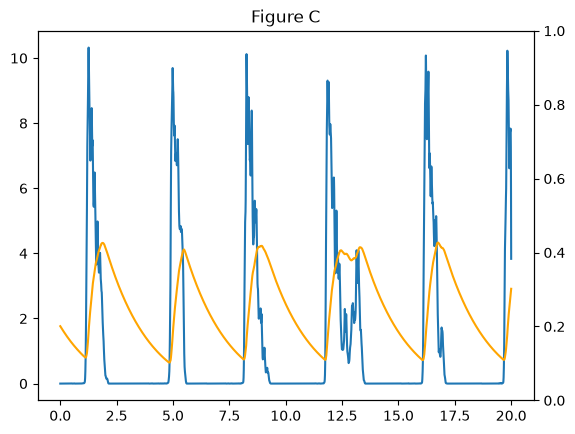

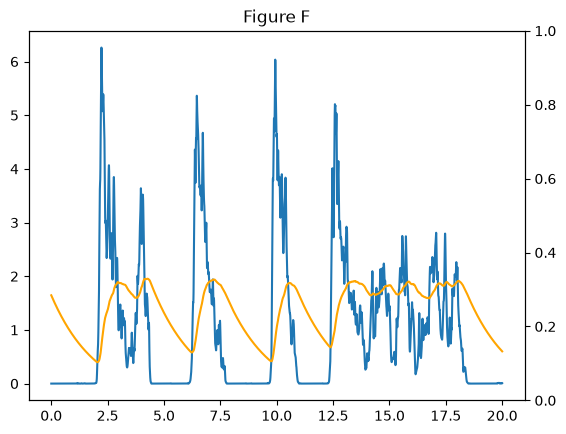

In [11]:
params = { "B": network_B(5, 1.0, 1.0, 0.08), 
          "C": network_B(5, 1.0, 1.2, 0.08), 
           "F": network_B(5, 1.2, 1.2, 0.08)}
        

def gaus(x, width):
    return 1 / width / np.sqrt(2 * np.pi) * np.exp(-1 / 2 * (x / width)**2)
window = gaus(np.arange(-30,30), 10)
for fig in params_s:
    res = None
    pkl_path = f"pkls/network_B/b_e-{params[fig][2].b_e}/b_i-{params[fig][2].b_i}/delta_g_k_ca-{params[fig][0].delta_g_k_ca}/I-{params[fig][0].i_max}.pkl.gzip"
        
    #res = run_sim(*params_s[fig], trace_g_k_ca=ExcitatoryAverageTraceType())
    #with gzip.open(pkl_path, "wb") as f:
    #    pkl.dump(res, f)
    
    with gzip.open(pkl_path, "rb") as f:
        res = pkl.load(f)
    
    t, spikes, _, g_k_ca_trace = res
    
    _, ax1 = plt.subplots()
    
    N_I = int(0.3 * 10000)
    excit_rates = np.convolve(window, spikes[50000:70000,N_I:].sum(axis=1)) / (10000 - N_I) * 1000 # / 10000 * 1000
    plt.title(f"Figure {fig}")
    ax1.plot((t[50000:70000] - 50000) / 1000, excit_rates[30:-29])
    ax2 = ax1.twinx()
    ax2.set_ylim(0,1)
    ax2.plot((t[50000:70000] - 50000) / 1000, g_k_ca_trace[50000:70000], color="orange")
    plt.show()